In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from src.data.dataloader import get_dataloaders
from src.models.biomass_model import BiomassModel
from src.utils.metrics import calculate_metrics

print(" Imports successful")

 Imports successful


Loading the validation data 

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

_, val_loader = get_dataloaders()

print("Validation batches:", len(val_loader))
print("Using device:", device)

Validation batches: 4
Using device: cpu


In [5]:
model = BiomassModel().to(device)

model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "best_model.pth",
        map_location=device
    )
)

model.eval()

print(" Biomass model loaded successfully!")

 Biomass model loaded successfully!


Genrate the prediction

In [6]:
all_predictions = []
all_targets = []

with torch.no_grad():

    for batch in val_loader:

        images = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        targets = batch["targets"].to(device)

        outputs = model(images, metadata)

        all_predictions.append(outputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

predictions = np.vstack(all_predictions)
targets = np.vstack(all_targets)

print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (57, 5)
Targets shape: (57, 5)


In [10]:
from sklearn.metrics import mean_squared_error
import inspect

print(mean_squared_error)
print(inspect.signature(mean_squared_error))

<function mean_squared_error at 0x000002E3AA94BAC0>
(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')


Calculating the evaluation metrics

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

target_names = [
    "Dry_Green_g",
    "Dry_Dead_g",
    "Dry_Clover_g",
    "Dry_Total_g",
    "GDM_g"
]

metrics = {}

for i, target in enumerate(target_names):

    mae = mean_absolute_error(
        targets[:, i],
        predictions[:, i]
    )

    mse = mean_squared_error(
        targets[:, i],
        predictions[:, i]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        targets[:, i],
        predictions[:, i]
    )

    metrics[target] = {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

metrics_df = pd.DataFrame(metrics).T

metrics_df

,MAE,RMSE,R2
Dry_Green_g,11.346119,16.735125,0.480582
Dry_Dead_g,8.822559,11.420528,-0.013921
Dry_Clover_g,7.107056,13.242271,0.046052
Dry_Total_g,12.494889,16.470585,0.614223
GDM_g,11.929630,15.586136,0.597082


Saving the mettrics

In [13]:
import json

reports_dir = PROJECT_ROOT / "outputs" / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

with open(reports_dir / "evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print(" Metrics saved !")

 Metrics saved !


Validation prediction

In [15]:
predictions_dir = PROJECT_ROOT / "outputs" / "predictions"
predictions_dir.mkdir(parents=True, exist_ok=True)

prediction_df = pd.DataFrame()

for i, target in enumerate(target_names):
    prediction_df[f"Actual_{target}"] = targets[:, i]
    prediction_df[f"Predicted_{target}"] = predictions[:, i]

prediction_df.to_csv(
    predictions_dir / "validation_predictions.csv",
    index=False
)

print("Validation predictions saved!")

Validation predictions saved!


Actual v predicted

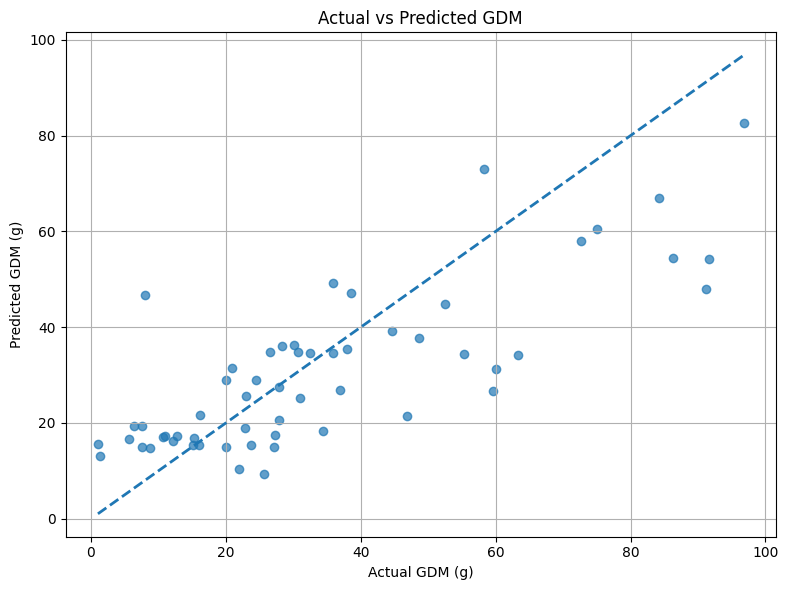

Saved actual_vs_predicted.png


In [17]:
plots_dir = PROJECT_ROOT / "outputs" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,6))

plt.scatter(
    targets[:, 4],
    predictions[:, 4],
    alpha=0.7
)

min_val = min(targets[:,4].min(), predictions[:,4].min())
max_val = max(targets[:,4].max(), predictions[:,4].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2
)

plt.xlabel("Actual GDM (g)")
plt.ylabel("Predicted GDM (g)")
plt.title("Actual vs Predicted GDM")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    plots_dir / "actual_vs_predicted.png",
    dpi=300
)

plt.show()

print("Saved actual_vs_predicted.png")

Residual plot

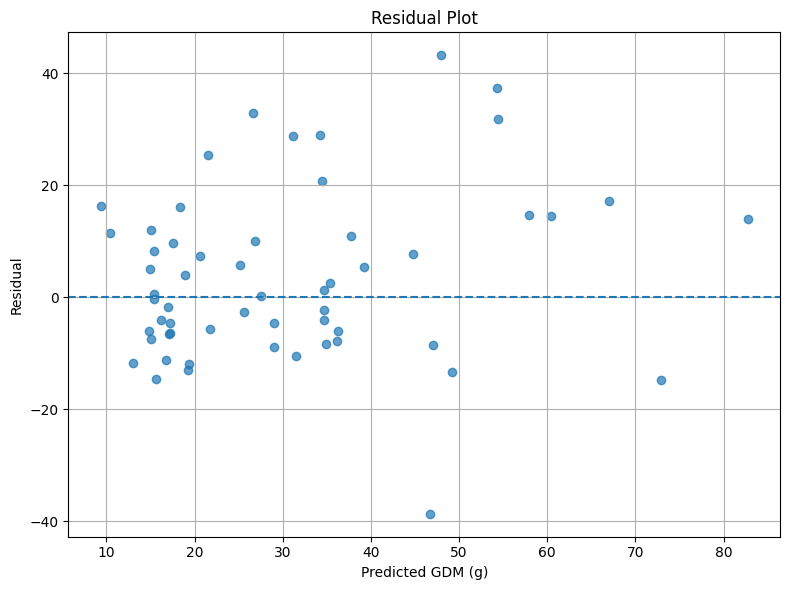

 Saved residual_plot.png


In [18]:
residuals = targets[:,4] - predictions[:,4]

plt.figure(figsize=(8,6))

plt.scatter(
    predictions[:,4],
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted GDM (g)")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    plots_dir / "residual_plot.png",
    dpi=300
)

plt.show()

print(" Saved residual_plot.png")

prediction ditribution

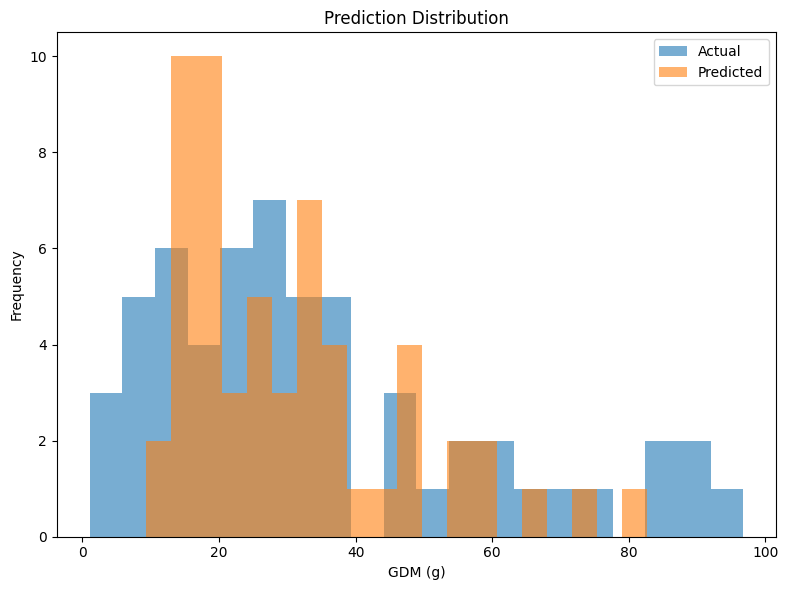

 Saved prediction_distribution.png


In [20]:
plt.figure(figsize=(8,6))

plt.hist(
    targets[:,4],
    bins=20,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    predictions[:,4],
    bins=20,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel("GDM (g)")
plt.ylabel("Frequency")

plt.title("Prediction Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    plots_dir / "prediction_distribution.png",
    dpi=300
)

plt.show()

print(" Saved prediction_distribution.png")

In [21]:
print(model)

BiomassModel(
  (feature_extractor): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNo